In [51]:
from scipy.integrate import odeint
import numpy as np 
import matplotlib.pyplot as plt

# Driven RLC Circuit
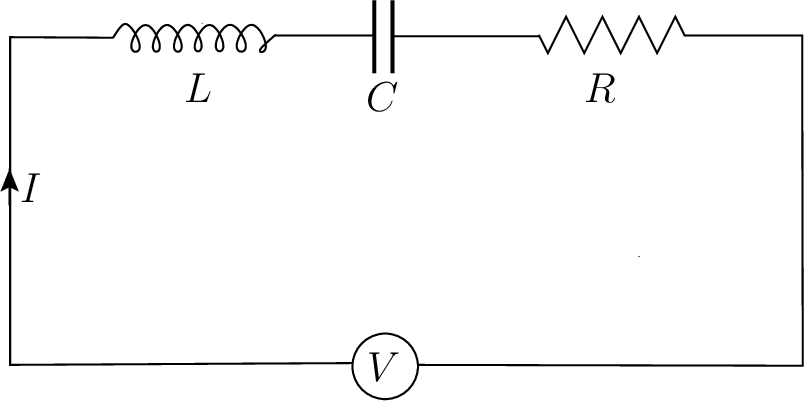

Applying Kirchhoff's Rule$$V(t)=V_{R}(t)+V_{L}(t)+V_{c}(t)$$

$$V_{0}\sin(\omega t)=IR+L \frac{dI}{dt}+\frac{Q}{C}$$

$$\begin{eqnarray}
\frac{d^{2}Q}{dt^{2}}&=&-\frac{R}{L} \frac{dQ}{dt}-\frac{Q}{LC}+\frac{V_{0}}{L}\sin \omega t 
\\ \frac{dI}{dt}&=& -\frac{R}{L} I-\frac{Q}{LC}+\frac{V_{0}}{L}\sin \omega t 
\end{eqnarray}$$

#### Using Euler-Cromer Method for numerical 
difference equation
$$\begin{eqnarray}
\frac{I_{i+1}-I_{i}}{dt}&=&-\frac{R}{L}I_{i}-\frac{Q_{i}}{LC}+\frac{V_{0}}{L}\sin \omega t_{i}\\\therefore I_{i+1}&=&I_{i}-\left( \frac{R}{L}I_{i}+\frac{Q_{i}}{LC}-\frac{V_{0}}{L}\sin \omega t_{i} \right) dt\\ \\ \frac{Q_{i+1}-Q_{i}}{dt}&=& I_{i+1}\\ \therefore Q_{i+1}&=& Q_{i}+I_{i+1}dt
\end{eqnarray}$$

In [52]:
# setting parameter values 
C=1e-6
L=5
R=1000
FD=10

dt=0.0001 # step size 
t = np.arange(0, 0.3+dt, dt) # creating time array from 0 to 0.3 with step size = dt


In [135]:
# function to calculate the analytical and numerical I, Q, V, P given omega 
def RLC (omega, C, L, R, FD, t, dt) :
    
    #Analytical Solution_________________________________________________________________________________________________________________

    # defining constants
    F0 = 10*omega/L 
    alpha = R/(2*L) 
    omega0 = 1/np.sqrt(L*C) 
    omegaD = np.sqrt(omega0**2-alpha**2) 
    D1 = (omega0**2-omega**2)**2-(2*alpha*omega)**2
    B1 = F0*(omega0**2-omega**2)/D1
    B2 = F0*(2*alpha*omega)/D1
    D2 = (omega0**2-omega**2)**2+(2*alpha*omega)**2 
    S1 = -F0*(2*alpha)/D2
    S2 = F0*(omega0**2-omega**2)/(D2*omega)

    # Equation for I (solved analytically)
    A_I = np.exp(-alpha*t)*(-B1*np.cos(omegaD*t) - ((alpha*B1+omega*B2)/omegaD)*np.sin(omegaD*t)) + B1*np.cos(omega*t) +B2*np.sin(omega*t)
    
    # Equation for Q (solved analytically) 
    A_Q = np.exp(-alpha*t)*(S1*np.cos(omegaD*t) + ((alpha*S1-omega*S2)/omegaD)*np.sin(omegaD*t)) + S1*np.cos(omega*t) +S2*np.sin(omega*t)    

    A_V = A_I*R + L*np.gradient(A_I)/dt +A_Q/C # calculating V = IR + L(dI/dt) + Q/C (using central derivative to calculate dI/dt)
    A_P = A_I*A_V #calculating P=IV

    #Numerical Solution (Euler-Cromer Method)____________________________________________________________________________________________ 
    #initializing array to store numerical values of I and Q
    N_I = np.zeros(len(t))
    N_Q = np.zeros(len(t))

    #initial values
    N_I[0] = 0
    N_Q[0] = 0
  
    #using Euler-Cromer method to calculate I,Q numerically and iterating over t array
    for i in range(len(t)-1):
        N_I[i+1]=N_I[i]-((R/L)*N_I[i]+N_Q[i]/(L*C)-(FD/L)*np.sin(omega*t[i]))*dt
        N_Q[i+1]=N_Q[i]+N_I[i+1]*dt

    N_V = N_I*R + L*np.gradient(N_I)/dt + N_Q/C #calculating V = IR + L(dI/dt) + Q/C (using 2-point central derivative to calculate dI/dt)
    N_P = N_I* N_V                             #calculating P=IV
    
    return A_Q ,A_I, A_V, A_P,  N_I, N_Q, N_V, N_P

    

In [136]:
A_Q50 ,A_I50, A_V50, A_P50,  N_I50, N_Q50, N_V50, N_P50 = RLC (50, C, L, R, FD, t, dt)
A_Q60 ,A_I60, A_V60, A_P60,  N_I60, N_Q60, N_V60, N_P60 = RLC (60, C, L, R, FD, t, dt)
A_Q100,A_I100,A_V100, A_P100,N_I100,N_Q100,N_V100, N_P100 = RLC (100, C, L, R, FD, t, dt)

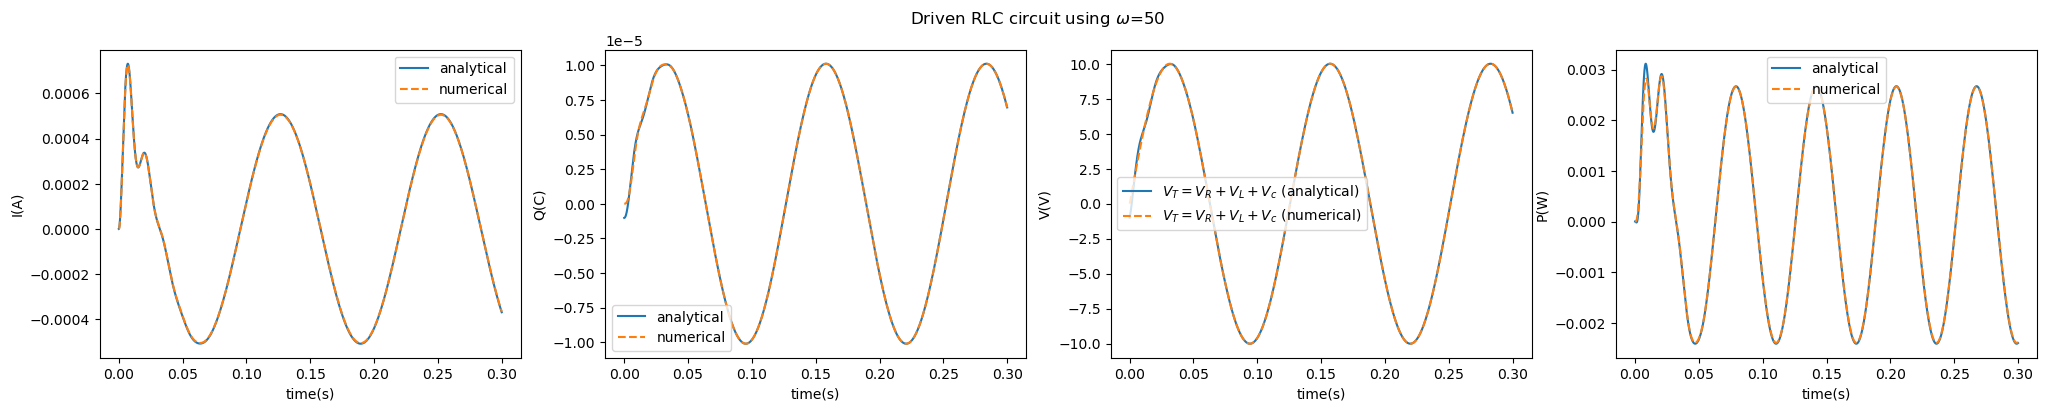

In [137]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(25, 4))

fig.suptitle(r'Driven RLC circuit using $\omega$=50')

ax1.plot(t,      A_I50,          label = 'analytical')
ax1.plot(t,      N_I50,     '--',label = 'numerical' )
ax2.plot(t,      A_Q50,          label = 'analytical')
ax2.plot(t,      N_Q50,     '--',label = 'numerical' )
ax3.plot(t, A_V50,         label = r'$V_T=V_{R}+V_{L}+V_{c}$ (analytical)')
ax3.plot(t, N_V50,     '--',label = r'$V_T=V_{R}+V_{L}+V_{c}$ (numerical)')
ax4.plot(t, A_P50,     label = 'analytical')
ax4.plot(t, N_P50,     '--',label = 'numerical')

ax1.set(ylabel=r'I(A)', xlabel=r'time(s)')
ax2.set(ylabel=r'Q(C)', xlabel=r'time(s)')
ax3.set(ylabel=r'V(V)', xlabel=r'time(s)')
ax4.set(ylabel=r'P(W)', xlabel=r'time(s)')
ax1.legend()
ax2.legend()
ax3.legend()
ax4.legend()
plt.savefig('Driven RLC circuit using omega=50.png')

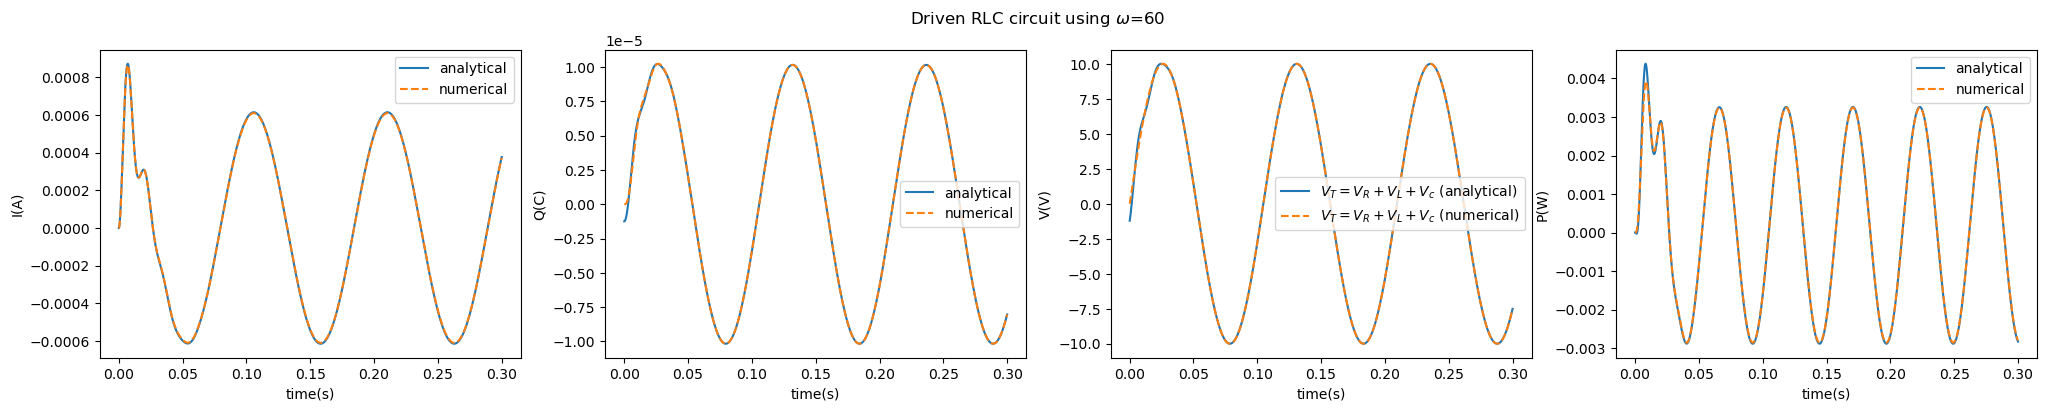

In [138]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(25, 4))

fig.suptitle(r'Driven RLC circuit using $\omega$=60')
#ax1.set_xlim(0,100)
#ax2.set_xlim(0,100)

ax1.plot(t,      A_I60,          label = 'analytical')
ax1.plot(t,      N_I60,     '--',label = 'numerical' )
ax2.plot(t,      A_Q60,          label = 'analytical')
ax2.plot(t,      N_Q60,     '--',label = 'numerical' )
ax3.plot(t, A_V60,         label = r'$V_T=V_{R}+V_{L}+V_{c}$ (analytical)')
ax3.plot(t, N_V60,     '--',label = r'$V_T=V_{R}+V_{L}+V_{c}$ (numerical)')
ax4.plot(t, A_P60,     label = 'analytical')
ax4.plot(t, N_P60,     '--',label = 'numerical')

#ax1.set_title(r"$F_D$ = 1.35")
#ax2.set_title(r"$F_D$ = 1.44")

ax1.set(ylabel=r'I(A)', xlabel=r'time(s)')
ax2.set(ylabel=r'Q(C)', xlabel=r'time(s)')
ax3.set(ylabel=r'V(V)', xlabel=r'time(s)')
ax4.set(ylabel=r'P(W)', xlabel=r'time(s)')
ax1.legend()
ax2.legend()
ax3.legend()
ax4.legend()
plt.savefig('Compare Analytical and Numerical RLC circuit using omega=60.png')

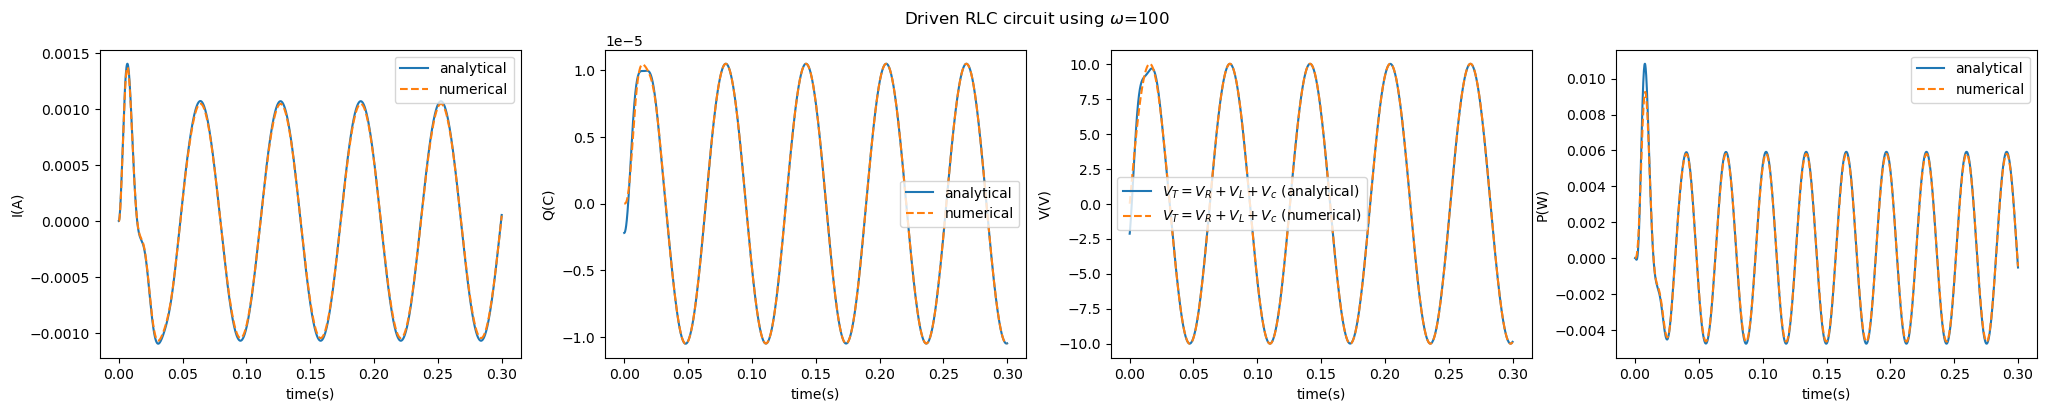

In [139]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(25, 4))

fig.suptitle(r'Driven RLC circuit using $\omega$=100')
#ax1.set_xlim(0,100)
#ax2.set_xlim(0,100)

ax1.plot(t,      A_I100,          label = 'analytical')
ax1.plot(t,      N_I100,     '--',label = 'numerical' )
ax2.plot(t,      A_Q100,          label = 'analytical')
ax2.plot(t,      N_Q100,     '--',label = 'numerical' )
ax3.plot(t, A_V100,         label = r'$V_T=V_{R}+V_{L}+V_{c}$ (analytical)')
ax3.plot(t, N_V100,     '--',label = r'$V_T=V_{R}+V_{L}+V_{c}$ (numerical)')
ax4.plot(t, A_P100,     label = 'analytical')
ax4.plot(t, N_P100,     '--',label = 'numerical')

#ax1.set_title(r"$F_D$ = 1.35")
#ax2.set_title(r"$F_D$ = 1.44")

ax1.set(ylabel=r'I(A)', xlabel=r'time(s)')
ax2.set(ylabel=r'Q(C)', xlabel=r'time(s)')
ax3.set(ylabel=r'V(V)', xlabel=r'time(s)')
ax4.set(ylabel=r'P(W)', xlabel=r'time(s)')
ax1.legend()
ax2.legend()
ax3.legend()
ax4.legend()
plt.savefig('Compare Analytical and Numerical RLC circuit using omega=100.png')

### Changing Omega 
(using analytical data) 

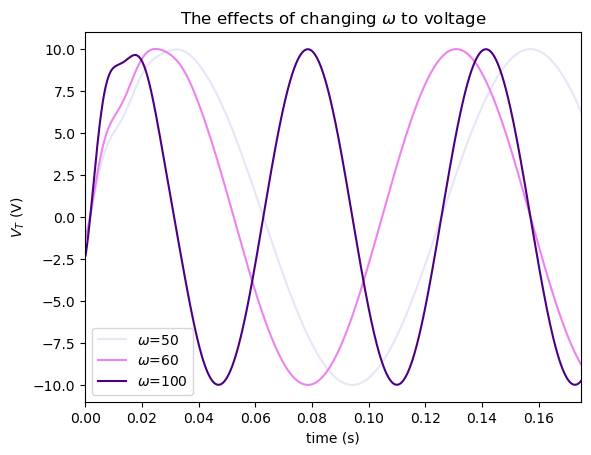

In [58]:
plt.plot(t, A_V50, label = r'$\omega$=50', color= 'lavender')
plt.plot(t, A_V60, label = r'$\omega$=60', color= 'violet' )
plt.plot(t, A_V100, label = r'$\omega$=100', color= 'indigo' )
plt.legend()
plt. xlim(0, 0.175)
plt.title(r'The effects of changing $\omega$ to voltage')
plt.xlabel('time (s)')  
plt.ylabel(r'$V_T$ (V)')
plt.savefig('The effects of changing omega to VT.png')

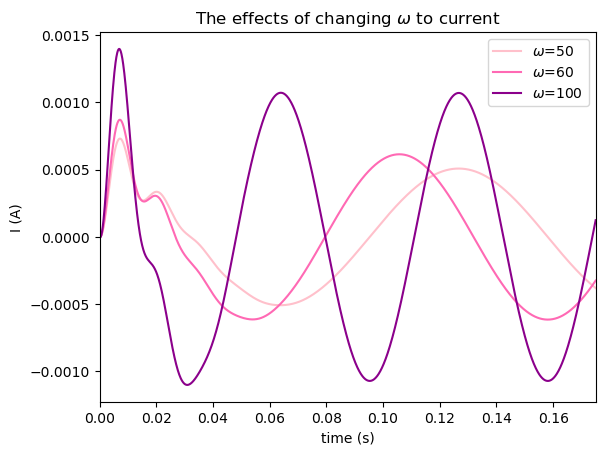

In [59]:
plt.plot(t, A_I50, label = r'$\omega$=50', color= 'pink')
plt.plot(t, A_I60, label = r'$\omega$=60', color= 'hotpink' )
plt.plot(t, A_I100, label =r'$\omega$=100', color= 'darkmagenta' )
plt.legend()
plt. xlim(0, 0.175)
plt.title(r'The effects of changing $\omega$ to current')
plt.xlabel('time (s)')  
plt.ylabel('I (A)')
plt.savefig('The effects of changing omega to IT.png')

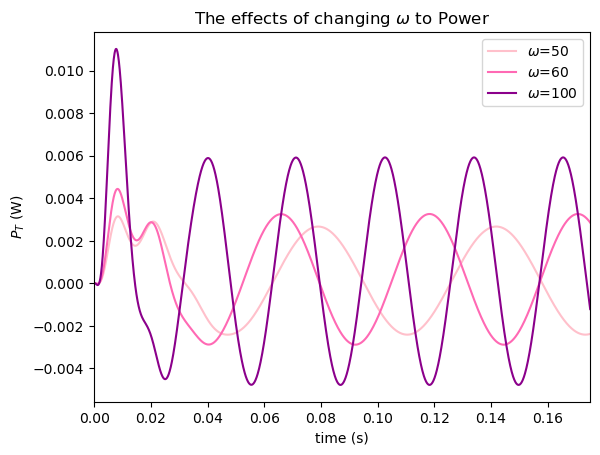

In [60]:
plt.plot(t, A_P50, label = r'$\omega$=50', color= 'pink')
plt.plot(t, A_P60, label = r'$\omega$=60', color= 'hotpink' )
plt.plot(t, A_P100, label =r'$\omega$=100', color= 'darkmagenta' )
plt.legend()
plt. xlim(0, 0.175)
plt.title(r'The effects of changing $\omega$ to Power')
plt.xlabel('time (s)')  
plt.ylabel(r'$P_T$ (W)')
plt.savefig('The effects of changing omega to PT.png')

## Voltage and Power components 
using $\omega=100$
- $V_{R}(t)=IR$
- $V_{L}(t)=L \frac{dI}{dt}$
- $V_{c}(t)=\frac{Q}{C}$

- $P_T = IV$
- $P_R = IV_R$
- $P_L = IV_L$
- $P_C = IV_C$

In [61]:
def VandP_components (V, I, Q, R, L, C, dt) : 

    VR = I*R
    VL = L*np.gradient(I)/dt
    VC = Q/C
    VT = VR+VL+VC

    
    PR = I*VR
    PL = I*VL
    PC = I*VC
    PT= PR+PL+PC
    
    return VT, VR, VL, VC, PT, PR, PL, PC

VT50_comp, VR50, VL50, VC50, PT50, PR50, PL50, PC50 = VandP_components (A_V50, A_I50, A_Q50, R, L, C, dt)
VT60_comp, VR60, VL60, VC60, PT60, PR60, PL60, PC60 = VandP_components (A_V60, A_I60, A_Q60, R, L, C, dt)
VT100_comp,  VR100, VL100, VC100, PT100, PR100, PL100, PC100 = VandP_components (A_V100, A_I100, A_Q100, R, L, C, dt)


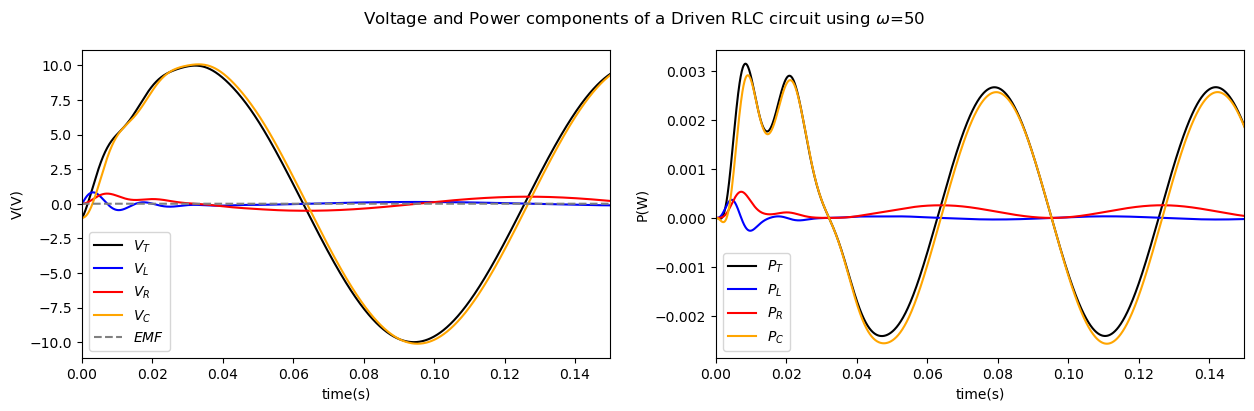

In [62]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))

fig.suptitle(r'Voltage and Power components of a Driven RLC circuit using $\omega$=50')

ax1.plot(t,      VT50_comp,     color = 'black' ,label = r'$V_T$',)
ax1.plot(t,      VL50,     color = 'blue'  ,label = r'$V_L $') 
ax1.plot(t,      VR50,     color = 'red'   ,label = r'$V_R $') 
ax1.plot(t,      VC50,     color = 'orange',label = r'$V_C $')

ax2.plot(t,      PT50,    color = 'black', label = r'$P_T$')
ax2.plot(t,      PL50,    color = 'blue',  label = r'$P_L $')
ax2.plot(t,      PR50,    color = 'red',   label = r'$P_R $')
ax2.plot(t,      PC50,    color = 'orange',label = r'$P_C $')

ax1.set(ylabel=r'V(V)', xlabel=r'time(s)')
ax1.legend()
ax2.set(ylabel=r'P(W)', xlabel=r'time(s)')
ax2.legend()
ax1.set_xlim(0,0.15)
ax2.set_xlim(0,0.15)
plt.savefig('Voltage and power components of a RLC circuit using omega=50.png')

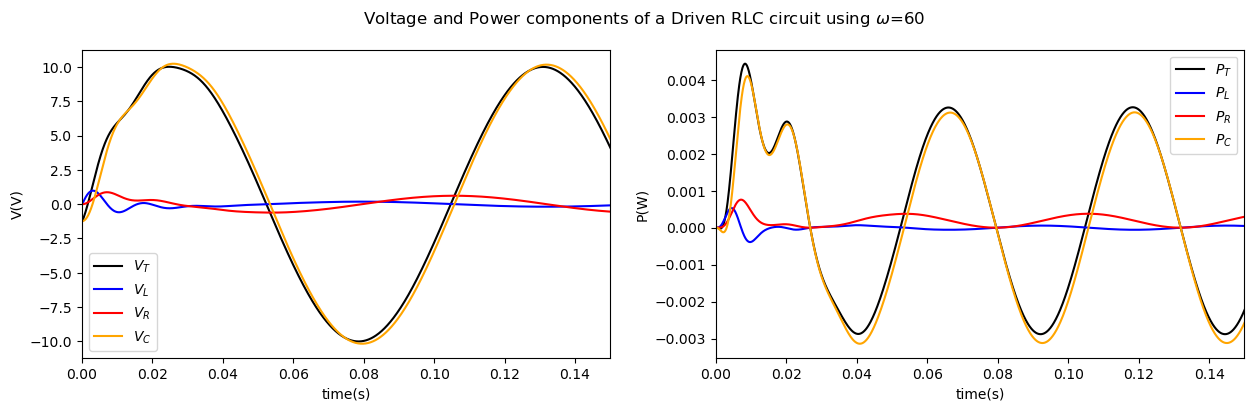

In [63]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))

fig.suptitle(r'Voltage and Power components of a Driven RLC circuit using $\omega$=60')

ax1.plot(t,      VT60_comp,     color = 'black' ,label = r'$V_T$',)
ax1.plot(t,      VL60,     color = 'blue'  ,label = r'$V_L $') 
ax1.plot(t,      VR60,     color = 'red'   ,label = r'$V_R $') 
ax1.plot(t,      VC60,     color = 'orange',label = r'$V_C $') 
#ax1.plot(t,      EMF60, '--',    color = 'pink' ,label = r'$EMF$',)

ax2.plot(t,      PT60,    color = 'black', label = r'$P_T$')
ax2.plot(t, PL60,    color = 'blue',  label = r'$P_L $')
ax2.plot(t,      PR60,    color = 'red',   label = r'$P_R $')
ax2.plot(t,      PC60,    color = 'orange',label = r'$P_C $')

ax1.set(ylabel=r'V(V)', xlabel=r'time(s)')
ax1.legend()
ax2.set(ylabel=r'P(W)', xlabel=r'time(s)')
ax2.legend()
ax1.set_xlim(0,0.15)
ax2.set_xlim(0,0.15)
plt.savefig('Voltage and power components of a RLC circuit using omega=60.png')

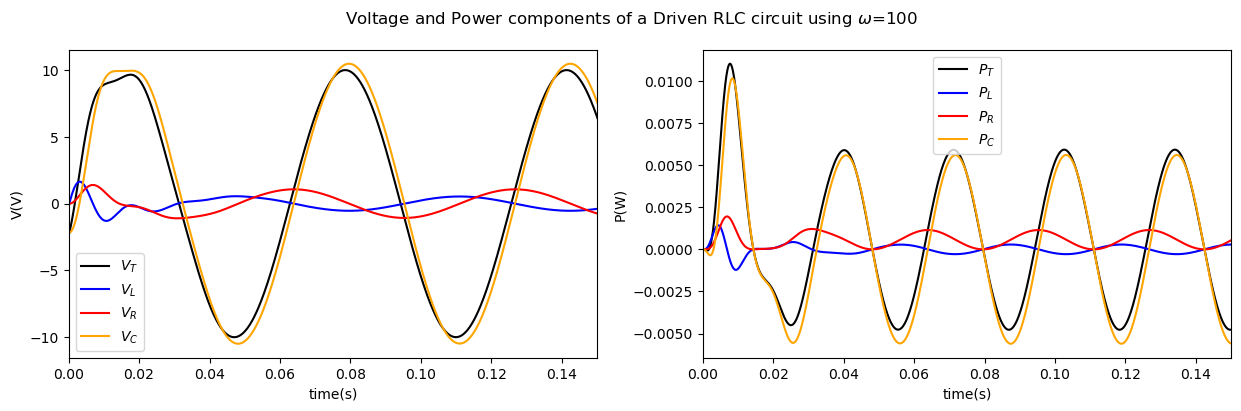

In [64]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))

fig.suptitle(r'Voltage and Power components of a Driven RLC circuit using $\omega$=100')


ax1.plot(t,      VT100_comp,     color = 'black' ,label = r'$V_T$',)
ax1.plot(t,      VL100,     color = 'blue'  ,label = r'$V_L $') 
ax1.plot(t,      VR100,     color = 'red'   ,label = r'$V_R $') 
ax1.plot(t,      VC100,     color = 'orange',label = r'$V_C $') 
#ax1.plot(t,      EMF100, '--',    color = 'pink' ,label = r'$EMF$',)

ax2.plot(t,      PT100,    color = 'black', label = r'$P_T$')
ax2.plot(t, PL100,    color = 'blue',  label = r'$P_L $')
ax2.plot(t,      PR100,    color = 'red',   label = r'$P_R $')
ax2.plot(t,      PC100,    color = 'orange',label = r'$P_C $')


ax1.set(ylabel=r'V(V)', xlabel=r'time(s)')
ax1.legend()
ax2.set(ylabel=r'P(W)', xlabel=r'time(s)')
ax2.legend()
ax1.set_xlim(0,0.15)
ax2.set_xlim(0,0.15)
plt.savefig('Voltage and power components of a RLC circuit using omega=100.png')

## Impedance, Z against frequency
to find resonance frequency, $f_r$
$$\begin{eqnarray}
X_{L}&=& X_{C}\\ \omega L&=& \frac{1}{\omega C}\\ \omega&=&\frac{1}{ \sqrt{LC}} = \frac{1}{\sqrt{5\times 1\mu}} = 441.21 rad/s
\end{eqnarray}$$

In [89]:
omega = np.arange(1,2000,0.01) # creating array to store values of frequency from 1 to 300 with step size 0.01

XC = 1/(omega*C) # Capacitive Reactance : 1/2pi*f*C
XL = omega*L # Inductive Reactance : 2pi*f*L

Z=np.sqrt(R**2+(XL-XC)**2) # Impedance : Z = √R^2+(XL-XC)^2

In [121]:
w0 = round(float(omega[np.where(Z == np.min(Z))[0]]),4) ## to find the resonant frequency where Z is minimum (which is the resonant frequency)
minZ = int(np.min(Z))

print('The Resonant Frequency is',w0, 'Hz and happens when Z =', minZ )

Imax = 10/Z
Pmax = 10*Imax


The Resonant Frequency is 447.21 Hz and happens when Z = 1000


C:\Users\Aisya Jasmin\AppData\Local\Temp\ipykernel_10916\4175324463.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  w0 = round(float(omega[np.where(Z == np.min(Z))[0]]),4) ## to find the resonant frequency where Z is minimum (which is the resonant frequency)


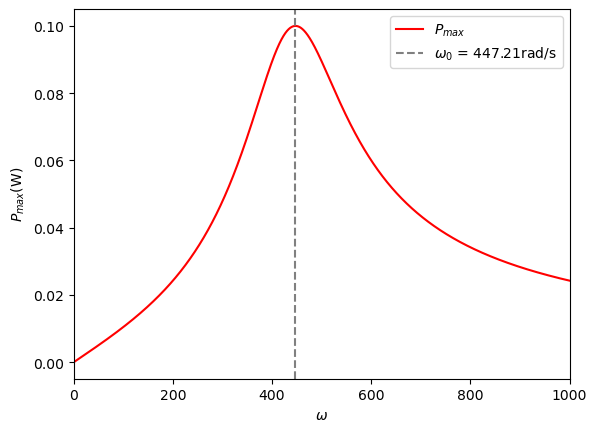

In [134]:

plt.plot(omega,Pmax, label = r'$P_{max}$', color = 'red') 

plt.axvline(w0, color='gray', linestyle='--', label=r'$\omega_0$ = 447.21rad/s')
plt.xlim(0,1000)
plt.ylabel(r'$P_{max}$(W)')
plt.xlabel(r'$\omega$')
plt.savefig('Pmax vs f.png')
plt.legend()

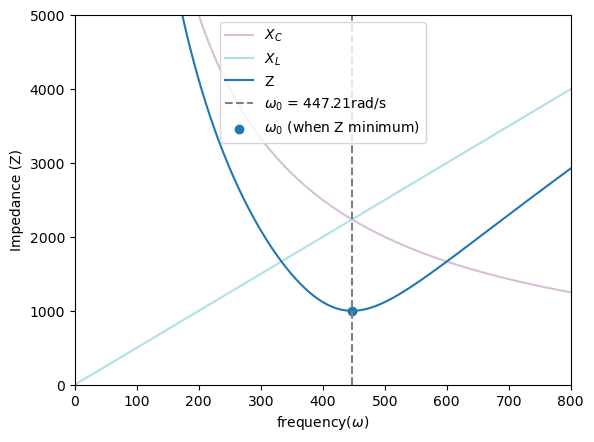

In [103]:
plt.plot(omega, XC, color = 'thistle', label = r'$X_C$')
plt.plot(omega, XL, color = 'powderblue', label = r'$X_L$')
plt.plot(omega,Z, label = 'Z') 

plt.axvline(w0, color='gray', linestyle='--', label=r'$\omega_0$ = 447.21rad/s')

plt.scatter(w0, minZ, label = r'$\omega_0$ (when Z minimum)')

plt.xlabel(r'frequency($\omega$)') 
plt.ylabel("Impedance (Z)") 
plt.ylim(0,5000)
plt.xlim(0,800)
plt.legend()
plt.savefig('Z vs f.png')

In [68]:
A_Q1000,A_I1000,A_V1000, A_P1000,  N_I1000, N_Q1000, N_V1000, N_P1000 = RLC (2*np.pi*fr, C, L, R, FD, t, dt)
VT1000, VR1000, VL1000, VC1000, PT1000, PR1000, PL1000, PC1000 = VandP_components (N_V1000, A_I1000, A_Q1000, R, L, C, dt)

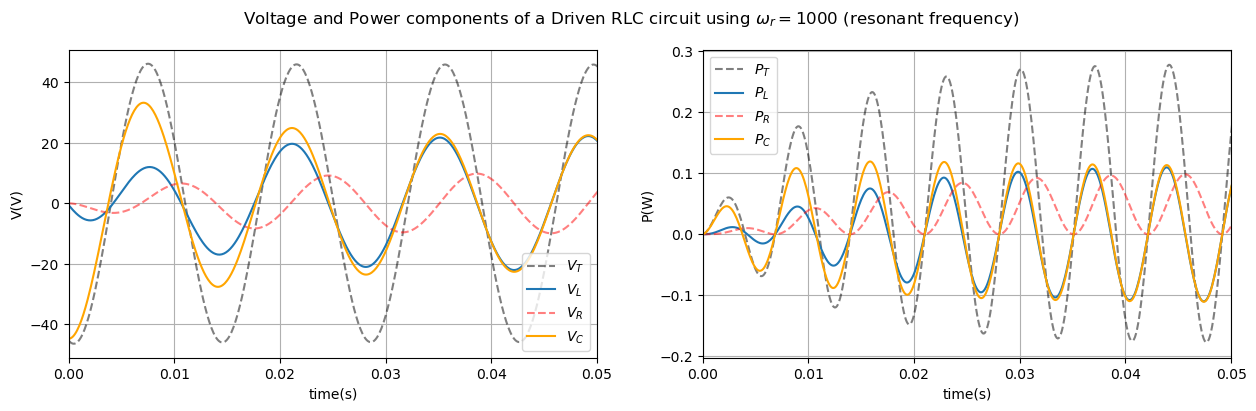

In [69]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))

fig.suptitle(r'Voltage and Power components of a Driven RLC circuit using $\omega_r=1000$ (resonant frequency)')
#ax1.set_xlim(0,100)
#ax2.set_xlim(0,100)6

ax1.plot(t,      VT1000, '--',    color = 'black' ,label = r'$V_T$', alpha=0.5)
ax1.plot(t,      VL1000,       label = r'$V_L $', ) 
ax1.plot(t,      VR1000, '--',    color = 'red'   ,label = r'$V_R $', alpha=0.5) 
ax1.plot(t,      VC1000,     color = 'orange',label = r'$V_C $') 

ax2.plot(t,      PT1000,  '--',  color = 'black', label = r'$P_T$', alpha=0.5)
ax2.plot(t,      PL1000,     label = r'$P_L $')
ax2.plot(t,      PR1000, '--',   color = 'red',   label = r'$P_R $',alpha=0.5)
ax2.plot(t,      PC1000,    color = 'orange',label = r'$P_C $')


#ax1.set_title(r"$F_D$ = 1.35")
#ax2.set_title(r"$F_D$ = 1.44")

ax1.set(ylabel=r'V(V)', xlabel=r'time(s)')
ax1.legend()
ax2.set(ylabel=r'P(W)', xlabel=r'time(s)')
ax2.legend()
ax1.set_xlim(0,0.05)
#ax1.set_ylim(-40, 40)
ax2.set_xlim(0,0.05)
ax1.grid()
ax2.grid()
plt.savefig('Voltage and power components of a RLC circuit using omega resonant.png')

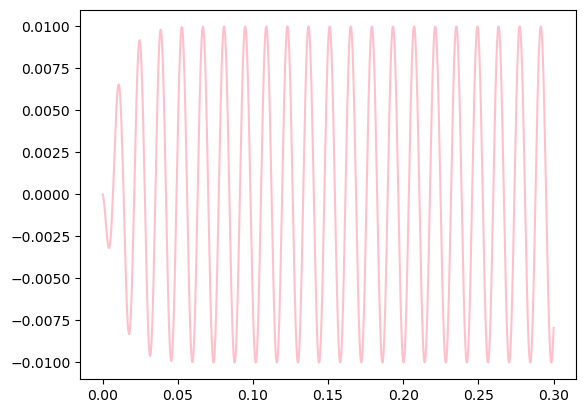

In [70]:
plt.plot(t,      A_I1000,     color = 'pink',label = r'$I $')